# cd_A_weakfaith 收敛性分析 (50-node ER1)

目标：在 50-node ER1, n=20000, noise_ratio=16 设定下，看清 `cd_A_weakfaith` 大约需要多少 iter 才能收敛。

**收敛定义** ：使用算法内置的 early-stop
- 每 `check_every = d*(d+1)//2 = 1275` 步检查一次
- 若相对改善 `(prev_f - curr_f) / max(1, |prev_f|) < tol` 持续 `patience` 次，停
- 默认 `tol=1e-4, patience=10, min_steps = 10 * check_every = 12750`
- 最早可能停步：`min_steps + patience * check_every = 25500`

**两组观察**
1. 单次跑到 `T_max=100K`，记录目标函数曲线 + CPDAG-SHD 在 log-spaced 检查点的轨迹 → 看「objective 收敛」与「图结构稳定」是否同步
2. 扫 `tol ∈ {1e-3, 1e-4, 1e-5, 1e-6}`，看不同收敛严格程度对应的 actual_T

## 1. 环境与配置

In [11]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / 'calm_dataset.py').exists() and (path / 'coordinate_descent').exists():
            return path
    raise RuntimeError(f'Could not find repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from calm_dataset import CalmDataset, weight_to_binary_adj
from coordinate_descent.cd_A_weakfaith import dag_coordinate_descent_l0_weakfaith
from dag_metrics import cpdag_shd, shd_directed, get_cpdag_shd_backend

print('Repo root            :', REPO_ROOT)
print('CPDAG-SHD backend    :', get_cpdag_shd_backend())

CFG = {
    'trials':       2,
    'seed':         42,
    'd':            50,
    'calm_degree':  2.0,       # 50-node ER1 -> s0 = 50 edges
    'graph_type':   'ER',
    'n_samples':    20000,
    'sem_type':     'gauss',
    'noise_ratio':  16.0,
    'noise_scale_mode': 'variance',
    'b_scale':      1.0,
    # cd_A_weakfaith
    'cd_T_max':     500000,    # 上限
    'cd_threshold': 0.05,
    'cd_lambda_l0': 0.2,
    'wf_tau':       0.05,
    'wf_screening': 'pcorr',
    'wf_combine':   'union',
    'wf_sampling_mode': 'preserve',
    # early-stop (与 paper-table7 那套一致)
    'es_tol':       1e-4,
    'es_patience':  10,
    'es_check_every': None,    # None -> d*(d+1)//2 = 1275 (d=50)
    'es_min_steps': None,      # None -> check_every * 10 = 12750
    # tol 扫描
    'tol_sweep':    [1e-3, 1e-4, 1e-5, 1e-6],
    # SHD 轨迹采样点数 (log-spaced)
    'shd_samples':  40,
}

_d = CFG['d']
_check_every = _d * (_d + 1) // 2
_min_steps   = _check_every * 10
_earliest_stop = _min_steps + CFG['es_patience'] * _check_every
print(f"\n50-ER1 早停参数 (d={_d}):")
print(f"  check_every  = {_check_every}")
print(f"  min_steps    = {_min_steps}")
print(f"  earliest stop ≈ {_earliest_stop} (= min_steps + patience*check_every)")
print(f"  T_max        = {CFG['cd_T_max']}")

Repo root            : C:\Users\super\DAG
CPDAG-SHD backend    : causaldag

50-ER1 早停参数 (d=50):
  check_every  = 1275
  min_steps    = 12750
  earliest stop ≈ 25500 (= min_steps + patience*check_every)
  T_max        = 500000


## 2. 数据生成 + 跑 cd_A_weakfaith (一次到 T_max，记录完整轨迹)

对每个 trial：
- `early_stop=True` 启用内部早停
- `return_history=True` → 拿到目标函数曲线
- `return_graph_history=True` → 拿到每步图快照，用于在 log-spaced 检查点上算 CPDAG-SHD
- 跑完立刻把 graph_history 在 log-spaced 索引处采样为 SHD 轨迹，然后 `del graph_history` 释放内存

In [12]:
def _sample_cov(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    return Xc.T @ Xc / Xc.shape[0]


def _make_dataset(seed):
    ds = CalmDataset(
        n=CFG['n_samples'], d=CFG['d'],
        graph_type=CFG['graph_type'], degree=CFG['calm_degree'],
        sem_type=CFG['sem_type'],
        seed=int(seed),
        noise_ratio=CFG['noise_ratio'],
        noise_scale_mode=CFG['noise_scale_mode'],
        b_scale=CFG['b_scale'],
    )
    G_true = weight_to_binary_adj(ds.B)
    return ds.X, G_true


rng = np.random.default_rng(CFG['seed'])
trial_seeds = rng.integers(0, 10**9, size=CFG['trials']).tolist()

trace_runs = []
shd_traj_rows = []

for trial_id, data_seed in enumerate(trial_seeds, 1):
    data_seed = int(data_seed)
    X, G_true = _make_dataset(data_seed)
    S = _sample_cov(X)
    n_edges_true = int(G_true.sum())

    t0 = time.perf_counter()
    A, G_est, final_obj, history, graph_history = dag_coordinate_descent_l0_weakfaith(
        S=S, T=CFG['cd_T_max'], seed=data_seed + 1,
        threshold=CFG['cd_threshold'],
        lambda_l0=CFG['cd_lambda_l0'],
        return_history=True,
        return_graph_history=True,
        early_stop=True,
        tol=CFG['es_tol'],
        patience=CFG['es_patience'],
        check_every=CFG['es_check_every'],
        min_steps=CFG['es_min_steps'],
        faithfulness_tau=CFG['wf_tau'],
        screening=CFG['wf_screening'],
        combine=CFG['wf_combine'],
        sampling_mode=CFG['wf_sampling_mode'],
    )
    runtime_sec = time.perf_counter() - t0

    actual_T   = len(history)
    early_stopped = actual_T < CFG['cd_T_max']
    final_shd  = shd_directed(G_true, G_est)
    final_cshd = cpdag_shd(G_true, G_est)

    # log-spaced 采样 SHD 轨迹
    sample_idx = np.unique(
        np.logspace(2, np.log10(max(actual_T - 1, 100)), CFG['shd_samples']).astype(int)
    )
    sample_idx = sample_idx[sample_idx < len(graph_history)]
    for t in sample_idx:
        G_t = graph_history[int(t)].astype(int)
        shd_traj_rows.append({
            'trial_id':   trial_id,
            'data_seed':  data_seed,
            'iter':       int(t),
            'cpdag_shd':  cpdag_shd(G_true, G_t),
            'shd':        shd_directed(G_true, G_t),
            'n_edges_est': int(G_t.sum()),
        })
    # 清掉 graph_history (~250MB) 再下一个 trial
    del graph_history

    trace_runs.append({
        'trial_id':        trial_id,
        'data_seed':       data_seed,
        'actual_T':        actual_T,
        'early_stopped':   early_stopped,
        'final_obj':       float(final_obj),
        'final_shd':       float(final_shd),
        'final_cpdag_shd': float(final_cshd),
        'n_edges_est':     int(G_est.sum()),
        'n_edges_true':    n_edges_true,
        'runtime_sec':     runtime_sec,
        'history':         np.asarray(history, dtype=np.float64),
    })
    print(
        f'[trial {trial_id}] data_seed={data_seed}  '
        f'actual_T={actual_T:6d}  early_stopped={early_stopped}  '
        f'cpdag_shd={final_cshd:5.1f}  shd={final_shd:5.0f}  '
        f'n_edges={int(G_est.sum())}/{n_edges_true}  '
        f'rt={runtime_sec:.1f}s'
    )

df_summary = pd.DataFrame([{k: v for k, v in r.items() if k != 'history'} for r in trace_runs])
display(df_summary)

df_traj = pd.DataFrame(shd_traj_rows)

[trial 1] data_seed=89250953  actual_T=500000  early_stopped=False  cpdag_shd= 25.0  shd=   29  n_edges=101/100  rt=426.8s
[trial 2] data_seed=773956048  actual_T=500000  early_stopped=False  cpdag_shd= 45.0  shd=   42  n_edges=116/100  rt=436.0s


,trial_id,data_seed,actual_T,early_stopped,final_obj,final_shd,final_cpdag_shd,n_edges_est,n_edges_true,runtime_sec
0,1,89250953,500000,False,158.571064,29.0,25.0,101,100,426.801264
1,2,773956048,500000,False,157.345406,42.0,45.0,116,100,435.969904


## 3. 目标函数收敛曲线

横轴 iter (log scale)。每个 trial 一条曲线，红色虚线标出该 trial 的 `actual_T`（早停触发位置）。

C:\Users\super\AppData\Local\Temp\ipykernel_38432\499115955.py:14: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\499115955.py:14: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\499115955.py:14: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\499115955.py:14: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\super\AppData\Roaming\Python\Python310\site

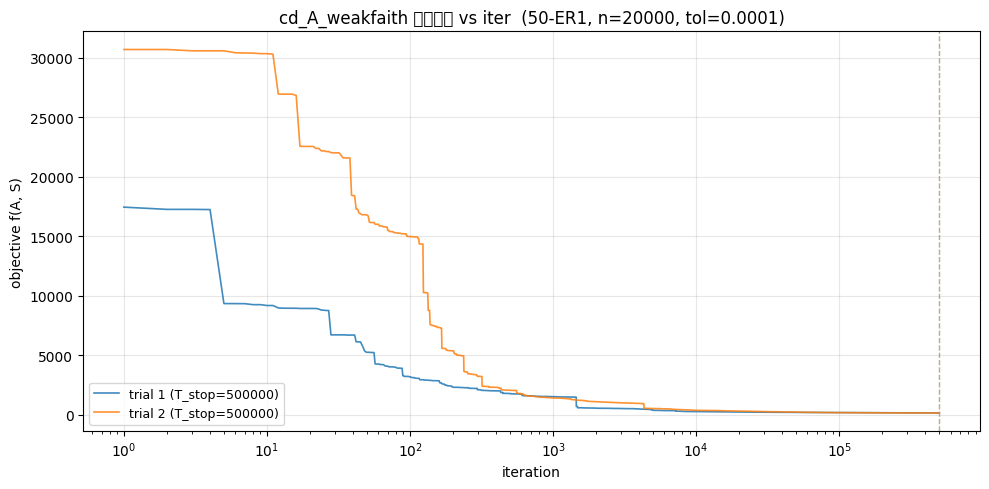

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for r in trace_runs:
    h = r['history']
    iters = np.arange(1, len(h) + 1)
    line, = ax.plot(iters, h, label=f"trial {r['trial_id']} (T_stop={r['actual_T']})",
                    alpha=0.85, linewidth=1.2)
    ax.axvline(r['actual_T'], color=line.get_color(), linestyle='--', alpha=0.4, linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('iteration')
ax.set_ylabel('objective f(A, S)')
ax.set_title(f"cd_A_weakfaith f(A, S) vs iter  (50-ER1, n={CFG['n_samples']}, tol={CFG['es_tol']:g})")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. CPDAG-SHD / SHD 随 iter 的变化

看图结构什么时候稳定下来，与目标函数的早停触发点对比。

C:\Users\super\AppData\Local\Temp\ipykernel_38432\3157207506.py:20: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\3157207506.py:20: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\3157207506.py:20: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\3157207506.py:20: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\super\AppData\Roaming\Python\Python310\

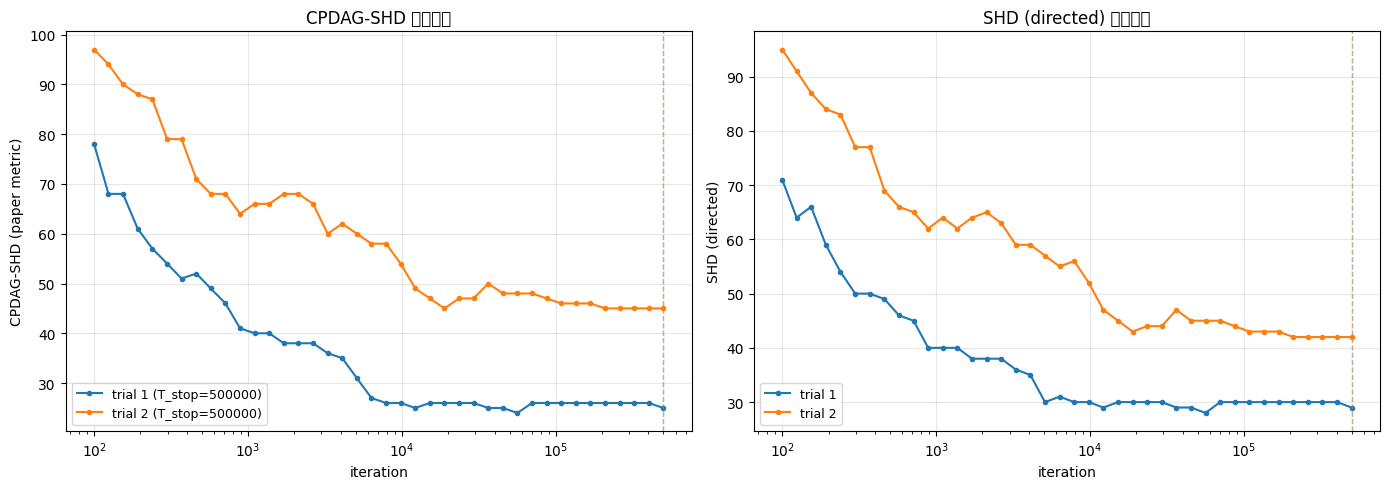

C:\Users\super\AppData\Local\Temp\ipykernel_38432\3157207506.py:37: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\3157207506.py:37: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\3157207506.py:37: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\3157207506.py:37: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_38432\3157207506.py:37: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: U

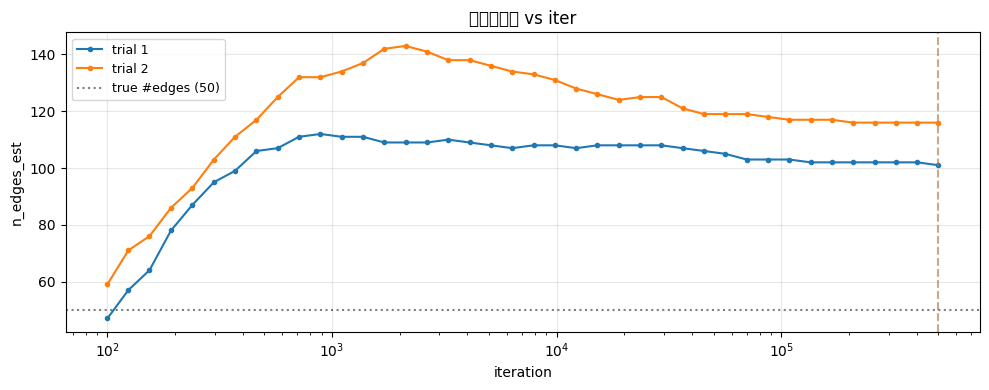

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in trace_runs:
    sub = df_traj[df_traj['trial_id'] == r['trial_id']]
    line, = axes[0].plot(sub['iter'], sub['cpdag_shd'], marker='.',
                          label=f"trial {r['trial_id']} (T_stop={r['actual_T']})")
    axes[0].axvline(r['actual_T'], color=line.get_color(), linestyle='--', alpha=0.4, linewidth=1)
    axes[1].plot(sub['iter'], sub['shd'], marker='.',
                 label=f"trial {r['trial_id']}", color=line.get_color())
    axes[1].axvline(r['actual_T'], color=line.get_color(), linestyle='--', alpha=0.4, linewidth=1)

for ax, ylabel in zip(axes, ['CPDAG-SHD (paper metric)', 'SHD (directed)']):
    ax.set_xscale('log')
    ax.set_xlabel('iteration')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
axes[0].set_title('CPDAG-SHD 收敛轨迹')
axes[1].set_title('SHD (directed) 收敛轨迹')
plt.tight_layout()
plt.show()

# 也画 n_edges_est 帮助直观理解
fig, ax = plt.subplots(figsize=(10, 4))
for r in trace_runs:
    sub = df_traj[df_traj['trial_id'] == r['trial_id']]
    line, = ax.plot(sub['iter'], sub['n_edges_est'], marker='.',
                    label=f"trial {r['trial_id']}")
    ax.axvline(r['actual_T'], color=line.get_color(), linestyle='--', alpha=0.4)
ax.axhline(50, color='k', linestyle=':', alpha=0.5, label='true #edges (50)')
ax.set_xscale('log')
ax.set_xlabel('iteration')
ax.set_ylabel('n_edges_est')
ax.set_title('n_edges_est vs iter')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. tol 扫描

固定其他参数，只改 `tol ∈ {1e-3, 1e-4, 1e-5, 1e-6}`，看 `actual_T` 怎么变。
每个 (trial × tol) 跑一遍，只用 `return_history=True` (不存 graph_history → 内存友好)。

In [15]:
# tol_rows = []
# for trial_id, data_seed in enumerate(trial_seeds, 1):
#     data_seed = int(data_seed)
#     X, G_true = _make_dataset(data_seed)
#     S = _sample_cov(X)
#     for tol in CFG['tol_sweep']:
#         t0 = time.perf_counter()
#         A, G_est, final_obj, history = dag_coordinate_descent_l0_weakfaith(
#             S=S, T=CFG['cd_T_max'], seed=data_seed + 1,
#             threshold=CFG['cd_threshold'],
#             lambda_l0=CFG['cd_lambda_l0'],
#             return_history=True,
#             early_stop=True,
#             tol=tol,
#             patience=CFG['es_patience'],
#             check_every=CFG['es_check_every'],
#             min_steps=CFG['es_min_steps'],
#             faithfulness_tau=CFG['wf_tau'],
#             screening=CFG['wf_screening'],
#             combine=CFG['wf_combine'],
#             sampling_mode=CFG['wf_sampling_mode'],
#         )
#         runtime = time.perf_counter() - t0
#         actual_T = len(history)
#         tol_rows.append({
#             'trial_id':       trial_id,
#             'tol':            tol,
#             'actual_T':       actual_T,
#             'early_stopped':  actual_T < CFG['cd_T_max'],
#             'cpdag_shd':      cpdag_shd(G_true, G_est),
#             'shd':            shd_directed(G_true, G_est),
#             'n_edges_est':    int(G_est.sum()),
#             'runtime_sec':    runtime,
#         })
#         print(f'[trial {trial_id}, tol={tol:g}] actual_T={actual_T:6d}  '
#               f'cpdag_shd={tol_rows[-1]["cpdag_shd"]:5.1f}  '
#               f'shd={tol_rows[-1]["shd"]:5.0f}  rt={runtime:.1f}s')

# df_tol = pd.DataFrame(tol_rows)
# df_tol_summary = (df_tol.groupby('tol', as_index=False)
#                   .agg(actual_T_mean=('actual_T', 'mean'),
#                        actual_T_std =('actual_T', 'std'),
#                        cpdag_shd_mean=('cpdag_shd', 'mean'),
#                        cpdag_shd_std =('cpdag_shd', 'std'),
#                        runtime_mean  =('runtime_sec', 'mean')))
# print('\n=== tol 扫描汇总 ===')
# display(df_tol_summary)

# fig, ax1 = plt.subplots(figsize=(8, 5))
# ax2 = ax1.twinx()
# for tid, sub in df_tol.groupby('trial_id'):
#     sub = sub.sort_values('tol', ascending=False)   # tol 大→小 = 收敛严格度递增
#     ax1.plot(sub['tol'], sub['actual_T'], marker='o', alpha=0.7,
#              label=f'trial {tid} actual_T')
#     ax2.plot(sub['tol'], sub['cpdag_shd'], marker='x', linestyle='--', alpha=0.6,
#              color=ax1.lines[-1].get_color(), label=f'trial {tid} cpdag_shd')
# ax1.set_xscale('log'); ax1.invert_xaxis()
# ax1.set_xlabel('tol (left=loose, right=strict)')
# ax1.set_ylabel('actual_T (实线圆)', color='C0')
# ax2.set_ylabel('CPDAG-SHD (虚线 ×)', color='C1')
# ax1.grid(alpha=0.3)
# ax1.set_title('tol 收紧 → actual_T 上升, CPDAG-SHD 是否再下降?')
# fig.tight_layout()
# plt.show()

## 6. 结论速读

- `actual_T` 的均值/范围：见第 2 节表格的 `actual_T` 列
- 对比目标函数曲线 (第 3 节) 与 CPDAG-SHD 曲线 (第 4 节)：
  - 如果 CPDAG-SHD 在 actual_T 之前就已稳定 → 默认 `tol=1e-4` 足够 (甚至偏严)
  - 如果 CPDAG-SHD 在 actual_T 之后还在下降 → 应该把 `tol` 收紧或加大 `T_max`
- tol 扫描 (第 5 节) 直接量化「收紧 tol 还能不能换来更好的 CPDAG-SHD」。
  - 如果 `tol` 从 1e-4 → 1e-6 时 `actual_T` 大幅增长但 CPDAG-SHD 不再变好 → 1e-4 是 sweet spot
  - 如果 CPDAG-SHD 仍在下降 → 应该用更严的 tol

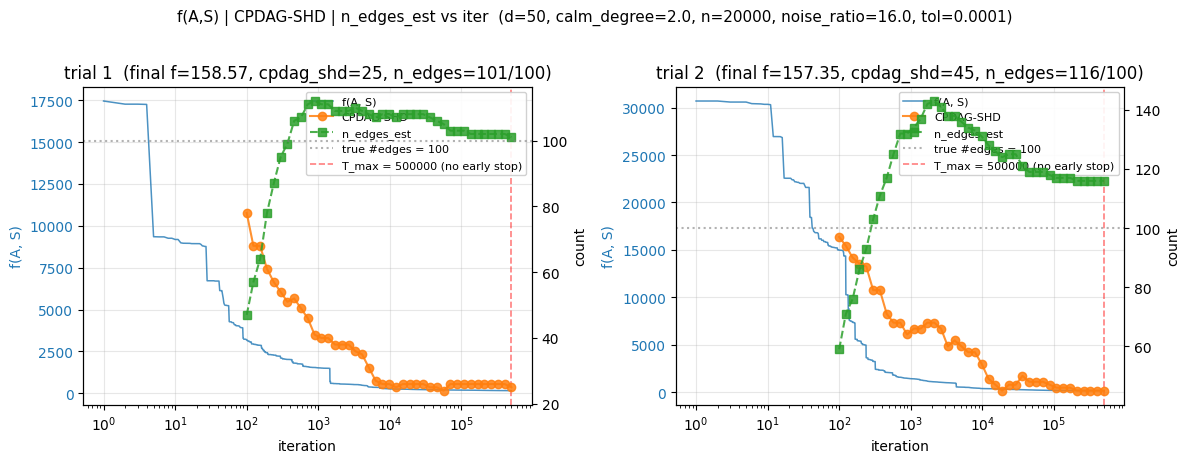

In [16]:
# 7. 同 trial 内三个量同时画：f(A,S) | CPDAG-SHD | n_edges_est vs iter
# 左 y 轴: 目标函数 (连续, 每 iter 一个值)
# 右 y 轴: CPDAG-SHD 与 n_edges_est (log-spaced 采样点; 同量级共用一根轴)
# 红色虚线: 该 trial 的 actual_T (早停触发位置, 若没触发则 = T_max)
# 灰色点线: 真实图的边数

fig, axes = plt.subplots(1, len(trace_runs),
                         figsize=(6 * len(trace_runs), 4.5),
                         squeeze=False)

for ax_obj, r in zip(axes[0], trace_runs):
    history = r['history']
    iters_h = np.arange(1, len(history) + 1)
    sub     = df_traj[df_traj['trial_id'] == r['trial_id']].sort_values('iter')

    # 左轴: f(A, S)
    color_obj = 'tab:blue'
    l_obj, = ax_obj.plot(iters_h, history, color=color_obj, alpha=0.8,
                         linewidth=1.1, label='f(A, S)')
    ax_obj.set_xscale('log')
    ax_obj.set_xlabel('iteration')
    ax_obj.set_ylabel('f(A, S)', color=color_obj)
    ax_obj.tick_params(axis='y', labelcolor=color_obj)
    ax_obj.grid(alpha=0.3)

    # 右轴: CPDAG-SHD 与 n_edges_est (同量级, 共用一根轴)
    ax_cnt = ax_obj.twinx()
    l_shd,  = ax_cnt.plot(sub['iter'], sub['cpdag_shd'],  marker='o',
                          color='tab:orange', alpha=0.85, label='CPDAG-SHD')
    l_edge, = ax_cnt.plot(sub['iter'], sub['n_edges_est'], marker='s',
                          linestyle='--', color='tab:green', alpha=0.85,
                          label='n_edges_est')
    l_true  = ax_cnt.axhline(r['n_edges_true'], color='gray', linestyle=':',
                              alpha=0.6,
                              label=f"true #edges = {r['n_edges_true']}")
    ax_cnt.set_ylabel('count', color='black')

    # 早停位置 (若 early_stopped=False, 这条线就在最右边, 仅作 T_max 参考)
    es_label = (f"actual_T = {r['actual_T']}" if r['early_stopped']
                else f"T_max = {r['actual_T']} (no early stop)")
    l_stop = ax_obj.axvline(r['actual_T'], color='red', linestyle='--',
                             alpha=0.5, linewidth=1.2, label=es_label)

    ax_obj.set_title(
        f"trial {r['trial_id']}  "
        f"(final f={history[-1]:.2f}, cpdag_shd={r['final_cpdag_shd']:.0f}, "
        f"n_edges={r['n_edges_est']}/{r['n_edges_true']})"
    )

    # 合并左右两轴的 legend 到一处
    handles = [l_obj, l_shd, l_edge, l_true, l_stop]
    labels  = [h.get_label() for h in handles]
    ax_obj.legend(handles, labels, loc='upper right', fontsize=8,
                  framealpha=0.9)

fig.suptitle(
    f"f(A,S) | CPDAG-SHD | n_edges_est vs iter  "
    f"(d={CFG['d']}, calm_degree={CFG['calm_degree']}, n={CFG['n_samples']}, "
    f"noise_ratio={CFG['noise_ratio']}, tol={CFG['es_tol']:g})",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()